# Web Scraping - Noticias do IBGE


## Imports e configurações

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import json
import pathlib

In [2]:
base_url = "https://agenciadenoticias.ibge.gov.br"
url_listagem = f"{base_url}/agencia-noticias.html"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36"
}

## Diagnóstico



In [3]:
resp_lista = requests.get(url_listagem, headers=headers, timeout=20)
print(f"Status HTTP: {resp_lista.status_code}")
print(f"URL final: {resp_lista.url}")
print(f"Tamanho do HTML: {len(resp_lista.text)} caracteres")

soup_lista = BeautifulSoup(resp_lista.text, "html.parser")
itens = soup_lista.find_all("div", class_="lista-noticias__item")
print(f"Itens de notícia encontrados na página 1: {len(itens)}")

link_teste = soup_lista.find("div", class_="lista-noticias__item").find("a")["href"]
if not link_teste.startswith("http"):
    link_teste = base_url + link_teste

print(f"Testando notícia individual: {link_teste}")
resp_noticia = requests.get(link_teste, headers=headers, timeout=20)
print(f"Status HTTP: {resp_noticia.status_code}")


Status HTTP: 200
URL final: https://agenciadenoticias.ibge.gov.br/agencia-noticias.html
Tamanho do HTML: 61357 caracteres
Itens de notícia encontrados na página 1: 19
Testando notícia individual: https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46411-estimativa-da-producao-de-cereais-leguminosas-e-oleaginosas-de-marco-de-2026-e-recorde-da-serie-historica
Status HTTP: 403


## Estrutura da listagem


## Coleta de dados diretamente da listagem


In [65]:
def extrair_itens_listagem(soup):
    registros = []
    itens = soup.find_all("div", class_="lista-noticias__item")

    for item in itens:
        a_foto = item.find("div", class_="lista-noticias__foto")
        link_tag = a_foto.find("a") if a_foto else None
        link = link_tag["href"] if link_tag else ""
        if link and not link.startswith("http"):
            link = base_url + link

        img_tag = item.find("img")
        img_url = img_tag["src"] if img_tag else ""
        if img_url and not img_url.startswith("http"):
            img_url = base_url + img_url

        sub_tag = item.find("p", class_="lista-noticias__subeditoria")
        subeditoria = sub_tag.get_text(strip=True) if sub_tag else ""

        h3 = item.find("h3")
        if h3:
            data_span = h3.find("span", class_="lista-noticias__data")
            data_str = data_span.get_text(strip=True) if data_span else ""
            if data_span:
                data_span.decompose()  
            titulo = h3.get_text(strip=True)
        else:
            titulo = ""
            data_str = ""

        resumo_tag = item.find("p", class_="mod-articles-category-introtext")
        resumo = resumo_tag.get_text(strip=True) if resumo_tag else ""

        registros.append({
            "url": link,
            "titulo": titulo,
            "subeditoria": subeditoria,
            "data": data_str,
            "resumo": resumo,
            "imagem": img_url,
        })

    return registros



## Iterando por todas as páginas de listagem


In [66]:
numero_paginas = 40   

todos_registros = []

for p in range(numero_paginas):
    start = p * 20
    url = f"{url_listagem}?start={start}"

    try:
        resp = requests.get(url, headers=headers, timeout=15)

        if resp.status_code != 200:
            print(f"Pagina {p+1}: HTTP {resp.status_code}: pulando")
            continue

        soup = BeautifulSoup(resp.text, "html.parser")
        registros = extrair_itens_listagem(soup)
        todos_registros.extend(registros)
        print(f"Pagina {p+1}/{numero_paginas} (start={start}): {len(registros)} noticias extraidas")

    except Exception as e:
        print(f"Pagina {p+1}: ERRO — {e}")

    time.sleep(5)

urls_vistas = set()
registros_unicos = []
for r in todos_registros:
    if r["url"] not in urls_vistas:
        urls_vistas.add(r["url"])
        registros_unicos.append(r)

print(f"Total de noticias únicas coletadas: {len(registros_unicos)}")

Pagina 1/40 (start=0): 20 noticias extraidas
Pagina 2/40 (start=20): 20 noticias extraidas
Pagina 3/40 (start=40): 20 noticias extraidas
Pagina 4/40 (start=60): 20 noticias extraidas
Pagina 5/40 (start=80): 20 noticias extraidas
Pagina 6/40 (start=100): 20 noticias extraidas
Pagina 7/40 (start=120): 20 noticias extraidas
Pagina 8/40 (start=140): 20 noticias extraidas
Pagina 9/40 (start=160): 20 noticias extraidas
Pagina 10/40 (start=180): 20 noticias extraidas
Pagina 11/40 (start=200): 20 noticias extraidas
Pagina 12/40 (start=220): 20 noticias extraidas
Pagina 13/40 (start=240): 20 noticias extraidas
Pagina 14/40 (start=260): 20 noticias extraidas
Pagina 15/40 (start=280): 20 noticias extraidas
Pagina 16/40 (start=300): 20 noticias extraidas
Pagina 17/40 (start=320): 20 noticias extraidas
Pagina 18/40 (start=340): 20 noticias extraidas
Pagina 19/40 (start=360): 20 noticias extraidas
Pagina 20/40 (start=380): 20 noticias extraidas
Pagina 21/40 (start=400): 20 noticias extraidas
Pagina 

## Capturando o texto completo de cada noticia


In [67]:
SELETOR_TEXTO = ("div", {"class": "texto--single"})  


def capturar_texto_completo(url):
    resultado = {
        "texto_completo": "",
        "erro": "",
    }
    try:
        resp = requests.get(url, headers=headers, timeout=15)

        if resp.status_code != 200:
            resultado["erro"] = f"HTTP {resp.status_code}"
            return resultado

        soup = BeautifulSoup(resp.text, "html.parser")

        corpo = soup.find(*SELETOR_TEXTO)

        resultado["texto_completo"] = corpo.get_text(separator="\n").strip()

        pub = soup.find("meta", property="article:published_time")

    except Exception as e:
        resultado["erro"] = str(e)  

    return resultado


url_teste = registros_unicos[0]["url"]
print(f"Testando: {url_teste}")
resultado_teste = capturar_texto_completo(url_teste)
print(f"Erro: {resultado_teste['erro'] or 'nenhum'}")
print(f"Texto (200 chars): {resultado_teste['texto_completo'][:200]}")

Testando: https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46398-ibge-realiza-workshop-de-experiencias-de-censos-de-populacao-em-situacao-de-rua
Erro: HTTP 403
Texto (200 chars): 


In [68]:
data_dir = pathlib.Path("data_ibge")
data_dir.mkdir(exist_ok=True)

for i, registro in enumerate(registros_unicos):
    url = registro["url"]
    resultado = capturar_texto_completo(url)

    if resultado["erro"]:
        print(f"[{i+1}/{len(registros_unicos)}] ERRO ({url}): {resultado['erro']}")
    else:
        print(f"[{i+1}/{len(registros_unicos)}] OK: {registro['titulo'][:60]}")

    registro.update(resultado)

    file_path = data_dir / f"noticia_{i:05d}.json"
    with file_path.open("w", encoding="utf-8") as f:
        json.dump(registro, f, ensure_ascii=False, indent=2)

    time.sleep(random.uniform(8, 11))

print(f"{len(registros_unicos)} noticias processadas.")

[1/800] ERRO (https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46398-ibge-realiza-workshop-de-experiencias-de-censos-de-populacao-em-situacao-de-rua): HTTP 403
[2/800] ERRO (https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46378-transportes-e-alimentacao-elevam-o-ipca-de-marco-para-0-88): HTTP 403
[3/800] ERRO (https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46380-precos-da-construcao-avancam-0-37-em-marco-com-destaque-para-regiao-nordeste): HTTP 403
[4/800] ERRO (https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46381-ibge-reune-ministerios-entidades-e-movimentos-sociais-em-reuniao-sobre-acoes-de-comunicacao-e-disseminacao-do-censo-agro): HTTP 403
[5/800] ERRO (https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46358-producao-industrial-avanca-0-9-e-cresce-em-11-dos-15-locais-pesquisados-em

KeyboardInterrupt: 

##  Salvando o CSV

In [ ]:
df = pd.DataFrame(registros_unicos)

colunas_desejadas = [
    "url", "titulo", "subeditoria", "data",
    "resumo", "texto_completo", "imagem"
]
df = df[[c for c in colunas_desejadas if c in df.columns]]

print(df.shape)
print(df.dtypes)
df.head()

(800, 10)
url                    object
titulo                 object
subeditoria            object
data                   object
resumo                 object
keywords               object
autor                  object
data_publicacao_iso    object
texto_completo         object
imagem                 object
dtype: object


,url,titulo,subeditoria,data,resumo,keywords,autor,data_publicacao_iso,texto_completo,imagem
0,https://agenciadenoticias.ibge.gov.br/agencia-...,IBGE realiza Workshop de Experiências de Censo...,IBGE,10/04/2026,"O IBGE realiza, de 13 a 15 de abril, no Rio de...",,,,,https://agenciadenoticias.ibge.gov.br/images/a...
1,https://agenciadenoticias.ibge.gov.br/agencia-...,Transportes e alimentação elevam o IPCA de mar...,IPCA,10/04/2026,"Em março, o Índice Nacional de Preços ao Consu...",,,,,https://agenciadenoticias.ibge.gov.br/images/a...
2,https://agenciadenoticias.ibge.gov.br/agencia-...,"Preços da construção avançam 0,37% em março, c...",Sinapi,10/04/2026,O Índice Nacional da Construção Civil (SINAPI)...,,,,,https://agenciadenoticias.ibge.gov.br/images/a...
3,https://agenciadenoticias.ibge.gov.br/agencia-...,"IBGE reúne ministérios, entidades e movimentos...",12º Censo Agro,09/04/2026,A Coordenação de Comunicação Social do Institu...,,,,,https://agenciadenoticias.ibge.gov.br/images/a...
4,https://agenciadenoticias.ibge.gov.br/agencia-...,"Produção industrial avança 0,9% e cresce em 11...",Indústria regional,09/04/2026,"Na passagem de janeiro para fevereiro, a produ...",,,,,https://agenciadenoticias.ibge.gov.br/images/a...


In [ ]:
df.to_csv("noticias_ibge_corrigidov2.csv", index=False, encoding="utf-8-sig")


Arquivo salvo: noticias_ibge.csv


## Análises dos dados

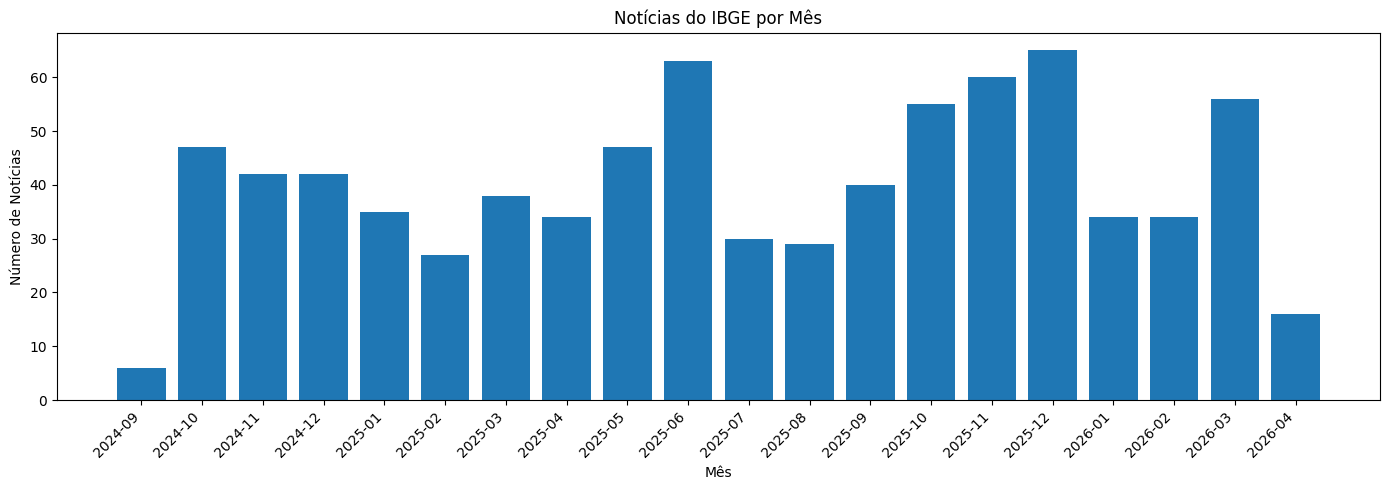

In [ ]:
import matplotlib.pyplot as plt

df["data_dt"] = pd.to_datetime(df["data"], format="%d/%m/%Y", errors="coerce")
df["ano_mes"] = df["data_dt"].dt.to_period("M").astype(str)

noticias_por_mes = df.groupby("ano_mes").size().reset_index(name="quantidade")
noticias_por_mes = noticias_por_mes.sort_values("ano_mes").tail(24)

plt.figure(figsize=(14, 5))
plt.bar(noticias_por_mes["ano_mes"], noticias_por_mes["quantidade"])
plt.xlabel("Mes")
plt.ylabel("Numero de Noticias")
plt.title("Noticias do IBGE por Mes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

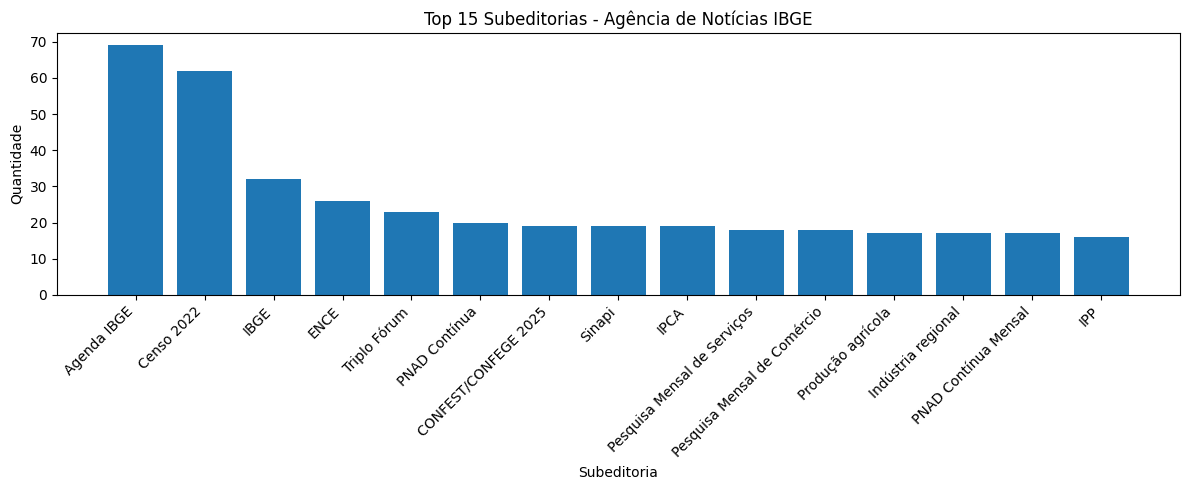

In [ ]:
top_sub = df["subeditoria"].replace("", pd.NA).dropna().value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_sub.index, top_sub.values)
plt.xlabel("Subeditoria")
plt.ylabel("Quantidade")
plt.title("Top 15 Subeditorias - Noticias IBGE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Resumo geral
print("=== Resumo do Dataset ===")
print(f"Total de noticias: {len(df)}")
print(f"Periodo: {df['data_dt'].min().date()} até {df['data_dt'].max().date()}")
print(f"Subeditorias unicas: {df['subeditoria'].nunique()}")
print("\nPreenchimento das colunas:")
for col in df.columns:
    preenchidos = df[col].replace("", pd.NA).notna().sum()
    print(f"  {col}: {preenchidos}/{len(df)} ({100*preenchidos//len(df)}%)")

=== Resumo do Dataset ===
Total de notícias: 800
Período: 2024-09-26 até 2026-04-10
Subeditorias únicas: 154

Preenchimento das colunas:
  url: 800/800 (100%)
  titulo: 800/800 (100%)
  subeditoria: 705/800 (88%)
  data: 800/800 (100%)
  resumo: 800/800 (100%)
  imagem: 800/800 (100%)
  texto_completo: 0/800 (0%)
  keywords: 0/800 (0%)
  autor: 0/800 (0%)
  data_publicacao_iso: 0/800 (0%)
  erro: 800/800 (100%)
  data_dt: 800/800 (100%)
  ano_mes: 800/800 (100%)
